# Electricity Demand Forecasting Using Machine Learning: A Time-Series Approach with Feature Engineering and Model Optimisation

### Import Libraries

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Dataset

In [4]:
df = pd.read_csv("historic_demand_2009_2024_noNaN.csv")
print(df.shape)


(278512, 19)


### Dataset Information

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278512 entries, 0 to 278511
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   settlement_date            278512 non-null  object
 1   settlement_period          278512 non-null  int64 
 2   period_hour                278512 non-null  object
 3   nd                         278512 non-null  int64 
 4   tsd                        278512 non-null  int64 
 5   england_wales_demand       278512 non-null  int64 
 6   embedded_wind_generation   278512 non-null  int64 
 7   embedded_wind_capacity     278512 non-null  int64 
 8   embedded_solar_generation  278512 non-null  int64 
 9   embedded_solar_capacity    278512 non-null  int64 
 10  non_bm_stor                278512 non-null  int64 
 11  pump_storage_pumping       278512 non-null  int64 
 12  ifa_flow                   278512 non-null  int64 
 13  ifa2_flow                  278512 non-null  

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
count,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000
mean,24.497357,31187.041370,32685.811143,28389.589217,1272.085027,4453.970263,880.245314,8705.061549,6.668416,304.497031,926.247609,53.998768,504.137998,-125.145276,-51.106742,176.336876,0.022405
std,13.852025,7831.306542,7598.781279,7091.113104,966.548452,1955.825654,1710.954426,5869.536138,39.197650,528.163447,1068.846762,354.179475,541.678428,230.383910,263.267266,422.130995,0.147996
min,1.000000,13367.000000,16513.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,-2056.000000,-1030.000000,-1215.000000,-505.000000,-585.000000,-1023.000000,0.000000
25%,12.000000,24907.750000,26608.000000,22676.750000,552.000000,2109.000000,0.000000,2046.000000,0.000000,8.000000,271.000000,0.000000,0.000000,-303.000000,-209.000000,0.000000,0.000000
50%,24.000000,30491.000000,31800.000000,27753.000000,1018.000000,4831.000000,0.000000,11503.000000,0.000000,11.000000,1183.000000,0.000000,726.000000,-148.000000,0.000000,0.000000,0.000000
75%,36.000000,36914.000000,38112.000000,33616.000000,1729.000000,6527.000000,889.000000,13080.000000,0.000000,366.000000,1892.000000,0.000000,994.000000,25.000000,0.000000,338.000000,0.000000
max,48.000000,59095.000000,60147.000000,53325.000000,5930.000000,6622.000000,11224.000000,17197.000000,893.000000,2019.000000,2066.000000,1016.000000,1143.000000,499.000000,504.000000,1033.000000,1.000000


### Data Cleaning

In [8]:
df["settlement_date"] = pd.to_datetime(df["settlement_date"])

df = df.sort_values("settlement_date")

df = df.set_index("settlement_date")

df.isnull().sum()

settlement_period            0
period_hour                  0
nd                           0
tsd                          0
england_wales_demand         0
embedded_wind_generation     0
embedded_wind_capacity       0
embedded_solar_generation    0
embedded_solar_capacity      0
non_bm_stor                  0
pump_storage_pumping         0
ifa_flow                     0
ifa2_flow                    0
britned_flow                 0
moyle_flow                   0
east_west_flow               0
nemo_flow                    0
is_holiday                   0
dtype: int64

### Resample Data

In [10]:
daily = df.resample("D").mean(numeric_only=True)

daily = daily.fillna(method="ffill")

daily.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8488\1858910507.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily = daily.fillna(method="ffill")


,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
settlement_date,,,,,,,,,,,,,,,,,
2009-01-01,24.5,37277.520833,38528.395833,33527.729167,65.666667,1403.0,0.0,0.0,0.000000,539.854167,1702.458333,0.0,0.0,-107.916667,0.0,0.0,1.0
2009-01-02,24.5,40015.020833,41133.458333,36087.083333,292.395833,1403.0,0.0,0.0,5.354167,391.500000,468.270833,0.0,0.0,-78.291667,0.0,0.0,0.0
2009-01-03,24.5,39535.229167,40667.791667,35530.187500,185.375000,1403.0,0.0,0.0,3.145833,441.958333,612.354167,0.0,0.0,-82.375000,0.0,0.0,0.0
2009-01-04,24.5,39820.979167,41013.958333,35889.770833,330.354167,1403.0,0.0,0.0,4.625000,474.104167,377.875000,0.0,0.0,-75.479167,0.0,0.0,0.0
2009-01-05,24.5,45450.958333,47322.312500,41006.854167,508.916667,1403.0,0.0,0.0,10.125000,554.875000,-506.291667,0.0,0.0,-93.250000,0.0,0.0,0.0


### Time Series Plot

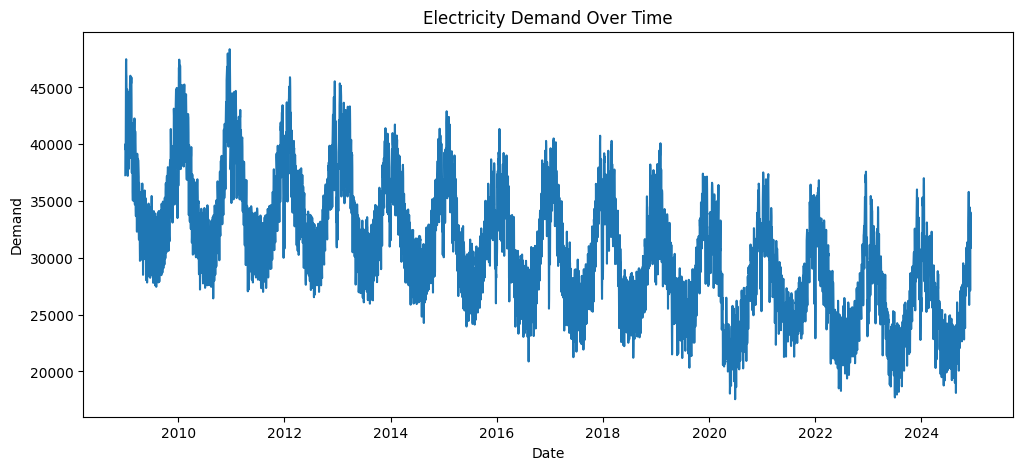

In [12]:
plt.figure(figsize=(12,5))

plt.plot(daily["nd"])

plt.title("Electricity Demand Over Time")

plt.xlabel("Date")

plt.ylabel("Demand")

plt.savefig("figure1_Electricity Demend over time.png", dpi=300)

plt.show()


### Distribution Plot

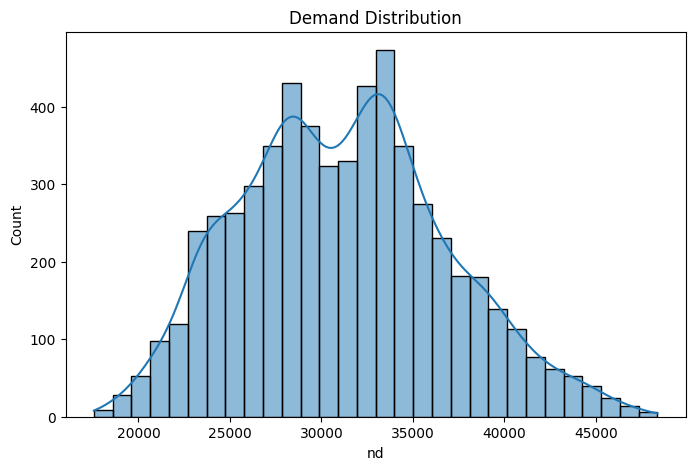

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(daily["nd"], bins=30, kde=True)

plt.title("Demand Distribution")
plt.savefig("figure2_Distribution Plot.png", dpi=300)
plt.show()

### Correlation Heatmap

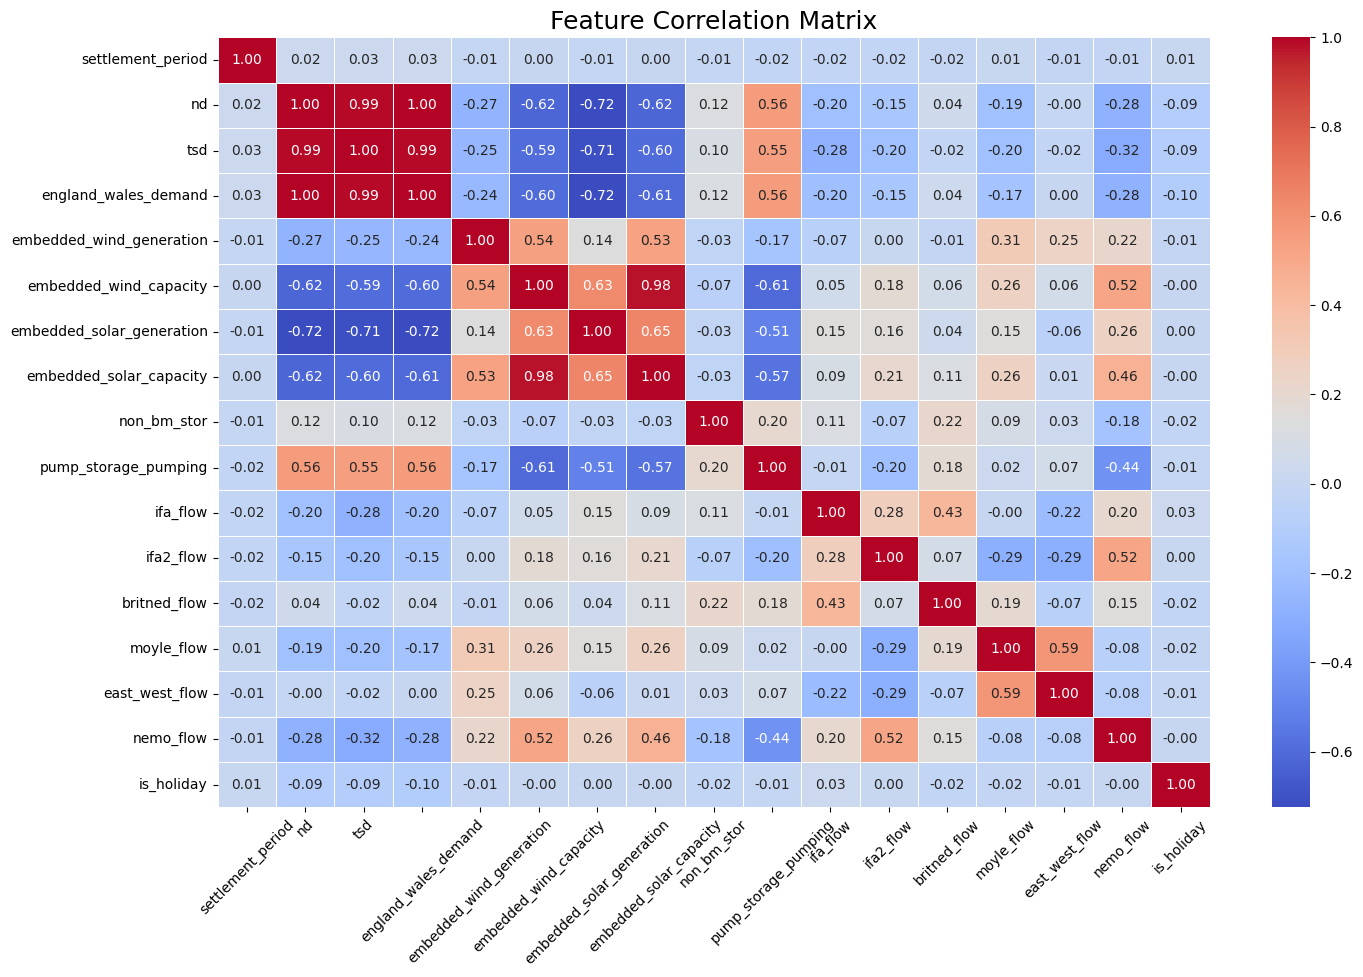

In [16]:
plt.figure(figsize=(16,10))

corr_matrix = daily.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10}
)

plt.title("Feature Correlation Matrix", fontsize=18)

plt.xticks(rotation=45)

plt.yticks(rotation=0)
plt.savefig("figure3_Correlation Heatmap.png", dpi=300)
plt.show()

### Feature Engineering

In [18]:
daily["lag_1"] = daily["nd"].shift(1)
daily["lag_7"] = daily["nd"].shift(7)

daily = daily.dropna()

daily.head()

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday,lag_1,lag_7
settlement_date,,,,,,,,,,,,,,,,,,,
2009-01-08,24.5,46168.250000,48029.958333,41786.541667,197.250000,1403.0,0.0,0.0,0.0,471.708333,-473.875000,0.0,0.0,-26.458333,0.0,0.0,0.0,47482.145833,37277.520833
2009-01-09,24.5,45964.291667,48309.708333,41639.312500,266.145833,1403.0,0.0,0.0,0.0,456.895833,-1029.958333,0.0,0.0,-109.479167,0.0,0.0,0.0,46168.250000,40015.020833
2009-01-10,24.5,42028.250000,43654.687500,38102.083333,742.708333,1403.0,0.0,0.0,0.0,407.166667,-378.958333,0.0,0.0,-107.666667,0.0,0.0,0.0,45964.291667,39535.229167
2009-01-11,24.5,39155.541667,40793.583333,35415.916667,1069.708333,1403.0,0.0,0.0,0.0,453.708333,-257.354167,0.0,0.0,-155.250000,0.0,0.0,0.0,42028.250000,39820.979167
2009-01-12,24.5,43611.625000,45563.166667,39521.833333,990.437500,1403.0,0.0,0.0,0.0,385.750000,-768.333333,0.0,0.0,-92.562500,0.0,0.0,0.0,39155.541667,45450.958333


### Define Features

In [20]:
X = daily[["lag_1","lag_7"]]

y = daily["nd"]

### Train/Test Split

In [22]:
split = int(len(daily)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

### Train Models

### Linear Regression Model

Linear Regression Results
MAE: 1329.9746
RMSE: 1727.7174
R2 Score: 0.8279


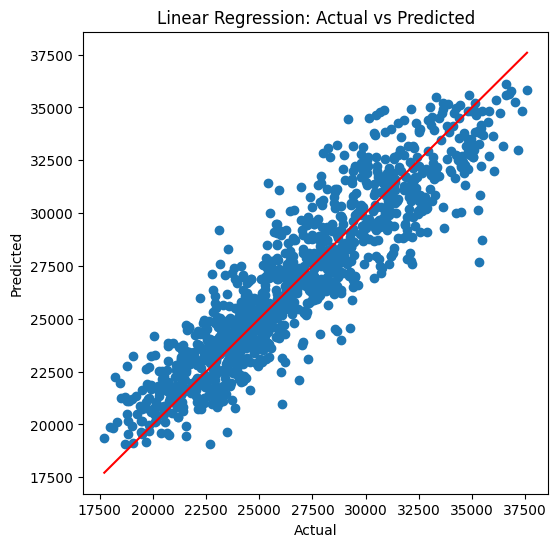

In [25]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test,y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2_lr = r2_score(y_test,y_pred_lr)

print("Linear Regression Results")
print("MAE:",round(mae_lr,4))
print("RMSE:",round(rmse_lr,4))
print("R2 Score:",round(r2_lr,4))

plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_lr)

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red")

plt.title("Linear Regression: Actual vs Predicted")

plt.xlabel("Actual")

plt.ylabel("Predicted")
plt.savefig("figure4_Linear Regression.png", dpi=300)
plt.show()

### Random Forest Regression Model

Random Forest Results
MAE: 1473.0529
RMSE: 1906.6705
R2 Score: 0.7904


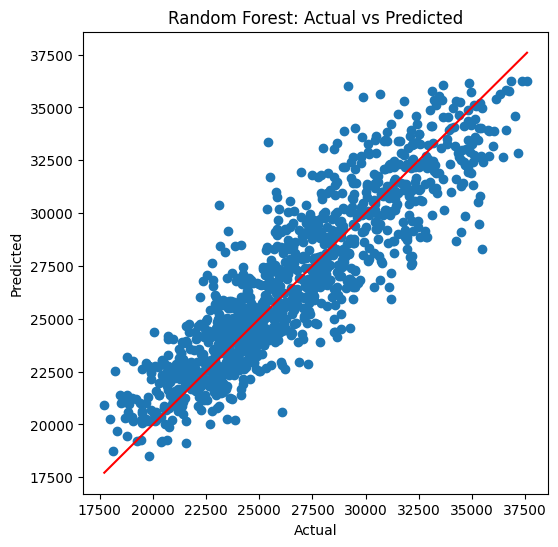

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest Results")
print("MAE:",round(mae_rf,4))
print("RMSE:",round(rmse_rf,4))
print("R2 Score:",round(r2_rf,4))

plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_rf)

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted")

plt.xlabel("Actual")

plt.ylabel("Predicted")
plt.savefig("figure5_Random Forest.png", dpi=300)
plt.show()

### XGBoost Model

XGBoost Results
MAE: 1409.3916
RMSE: 1826.9777
R2 Score: 0.8075


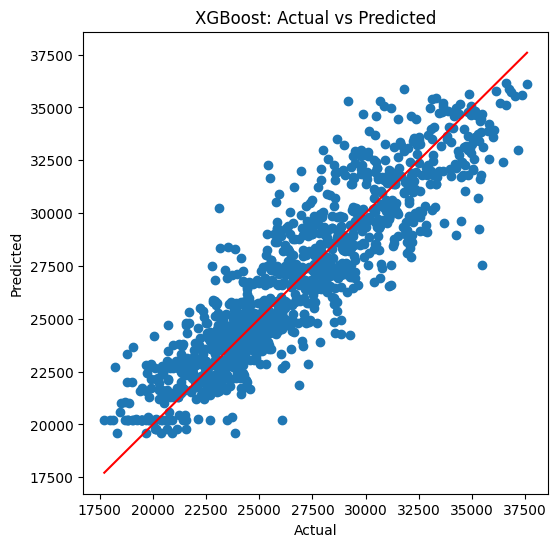

In [29]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train,y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test,y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
r2_xgb = r2_score(y_test,y_pred_xgb)

print("XGBoost Results")
print("MAE:",round(mae_xgb,4))
print("RMSE:",round(rmse_xgb,4))
print("R2 Score:",round(r2_xgb,4))

plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_xgb)

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red")

plt.title("XGBoost: Actual vs Predicted")

plt.xlabel("Actual")

plt.ylabel("Predicted")
plt.savefig("figure6_XGBoost.png", dpi=300)
plt.show()

### Model Comparison Table (Before Tuning)

In [31]:
results_before = []

results_before.append(["Linear Regression", mae_lr, rmse_lr, r2_lr])
results_before.append(["Random Forest", mae_rf, rmse_rf, r2_rf])
results_before.append(["XGBoost", mae_xgb, rmse_xgb, r2_xgb])

comparison_before = pd.DataFrame(
    results_before,
    columns=["Model", "MAE", "RMSE", "R2"]
)

comparison_before

,Model,MAE,RMSE,R2
0,Linear Regression,1329.974563,1727.717378,0.827886
1,Random Forest,1473.052929,1906.670459,0.790385
2,XGBoost,1409.391645,1826.977679,0.807542


### Final Comparison Plot

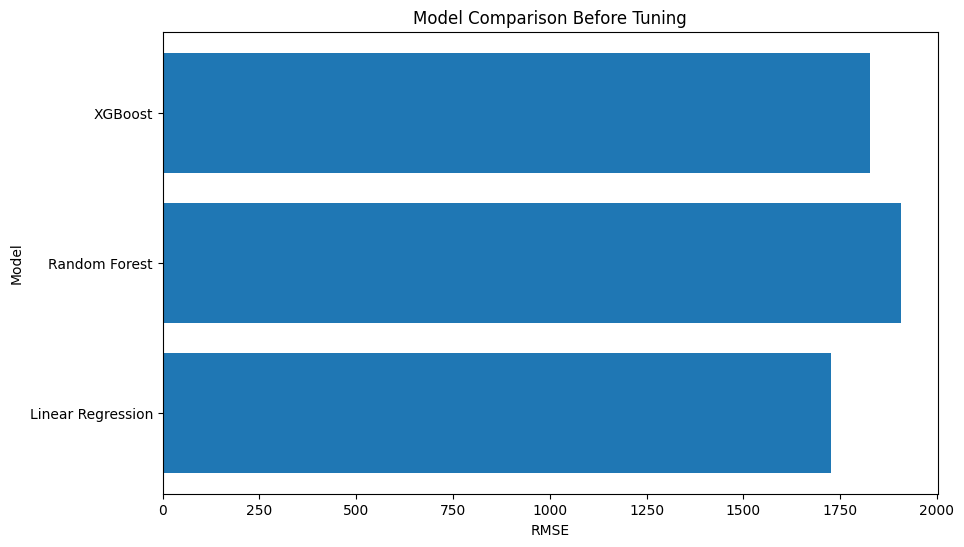

In [33]:
plt.figure(figsize=(10,6))

plt.barh(comparison_before["Model"],
         comparison_before["RMSE"])

plt.title("Model Comparison Before Tuning")

plt.xlabel("RMSE")

plt.ylabel("Model")
plt.savefig("figure7_Model Comparison.png", dpi=300)
plt.show()

In [34]:
tscv = TimeSeriesSplit(n_splits=3)

### Linear Regression Tuning

In [36]:
lr_param_grid = {
    "fit_intercept":[True,False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    lr_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

lr_grid.fit(X_train,y_train)

best_lr = lr_grid.best_estimator_

print("Best LR Parameters:",lr_grid.best_params_)

y_pred_lr_tuned = best_lr.predict(X_test)

mae_lr_tuned = mean_absolute_error(y_test,y_pred_lr_tuned)
rmse_lr_tuned = np.sqrt(mean_squared_error(y_test,y_pred_lr_tuned))
r2_lr_tuned = r2_score(y_test,y_pred_lr_tuned)

print("Tuned Linear Regression Results")
print("MAE:",round(mae_lr_tuned,4))
print("RMSE:",round(rmse_lr_tuned,4))
print("R2:",round(r2_lr_tuned,4))

Best LR Parameters: {'fit_intercept': True}
Tuned Linear Regression Results
MAE: 1329.9746
RMSE: 1727.7174
R2: 0.8279


### Random Forest Tuning

In [38]:
rf_param_grid = {
    "n_estimators":[25,50,100,200],
    "max_depth":[1,5,10,15]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

rf_grid.fit(X_train,y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Parameters:",rf_grid.best_params_)

y_pred_rf_tuned = best_rf.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test,y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test,y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test,y_pred_rf_tuned)

print("Tuned Random Forest Results")
print("MAE:",round(mae_rf_tuned,4))
print("RMSE:",round(rmse_rf_tuned,4))
print("R2:",round(r2_rf_tuned,4))

Best RF Parameters: {'max_depth': 5, 'n_estimators': 50}
Tuned Random Forest Results
MAE: 1431.3249
RMSE: 1875.0139
R2: 0.7973


### XGBoost Tuning

In [40]:
xgb_param_grid = {
    "n_estimators":[100,200,300,400],
    "learning_rate":[0.01,0.05,0.10,0.15],
    "max_depth":[0,2,4,6]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

xgb_grid.fit(X_train,y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGB Parameters:",xgb_grid.best_params_)

y_pred_xgb_tuned = best_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test,y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test,y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test,y_pred_xgb_tuned)

print("Tuned XGBoost Results")
print("MAE:",round(mae_xgb_tuned,4))
print("RMSE:",round(rmse_xgb_tuned,4))
print("R2:",round(r2_xgb_tuned,4))

Best XGB Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Tuned XGBoost Results
MAE: 1393.485
RMSE: 1801.3326
R2: 0.8129


### Comparison Table After Tuning

In [42]:
results_after = []

results_after.append(["Linear Regression Tuned",mae_lr_tuned,rmse_lr_tuned,r2_lr_tuned])
results_after.append(["Random Forest Tuned",mae_rf_tuned,rmse_rf_tuned,r2_rf_tuned])
results_after.append(["XGBoost Tuned",mae_xgb_tuned,rmse_xgb_tuned,r2_xgb_tuned])

comparison_after = pd.DataFrame(
    results_after,
    columns=["Model","MAE","RMSE","R2"]
)

comparison_after

,Model,MAE,RMSE,R2
0,Linear Regression Tuned,1329.974563,1727.717378,0.827886
1,Random Forest Tuned,1431.324948,1875.013864,0.797288
2,XGBoost Tuned,1393.484966,1801.332578,0.812907


### Final Comparison Plot

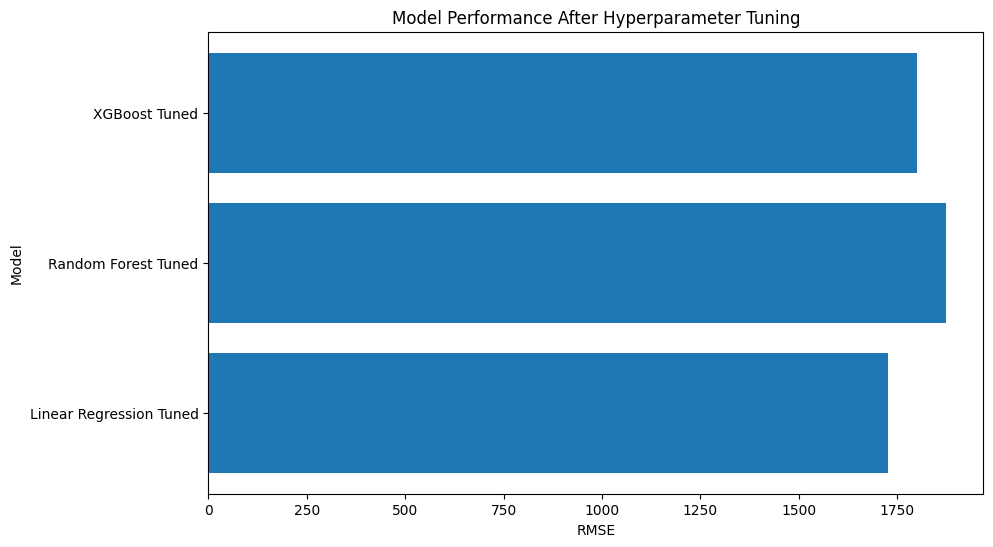

In [44]:
plt.figure(figsize=(10,6))

plt.barh(comparison_after["Model"],
         comparison_after["RMSE"])

plt.title("Model Performance After Hyperparameter Tuning")

plt.xlabel("RMSE")

plt.ylabel("Model")
plt.savefig("figure8_Model performance After Tuning.png", dpi=300)
plt.show()

### Comparison Table After And Before Tuning

In [46]:
before_rmse = comparison_before.set_index("Model")["RMSE"]

after_rmse = comparison_after.set_index("Model")["RMSE"]

comparison_plot = pd.concat([before_rmse, after_rmse], axis=1)

comparison_plot.columns = ["Before Tuning", "After Tuning"]

comparison_plot

,Before Tuning,After Tuning
Model,,
Linear Regression,1727.717378,NaN
Random Forest,1906.670459,NaN
XGBoost,1826.977679,NaN
Linear Regression Tuned,NaN,1727.717378
Random Forest Tuned,NaN,1875.013864
XGBoost Tuned,NaN,1801.332578


### Before vs After Tuning RMSE Plot

<Figure size 1000x600 with 0 Axes>

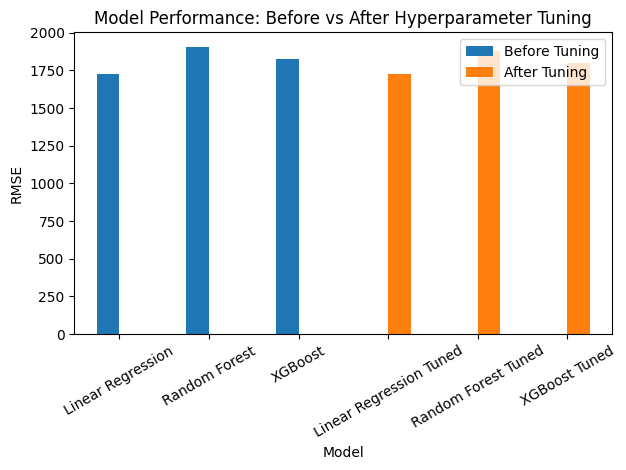

In [48]:
plt.figure(figsize=(10,6))

comparison_plot.plot(kind="bar")

plt.title("Model Performance: Before vs After Hyperparameter Tuning")

plt.ylabel("RMSE")

plt.xlabel("Model")

plt.xticks(rotation=30)

plt.legend()

plt.tight_layout()
plt.savefig("Model Performance before and after tuning.png", dpi=300)
plt.show()

### Linear Regression Cross Validation

In [50]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
tscv = TimeSeriesSplit(n_splits=5)
lr_cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

lr_rmse_scores = -lr_cv_scores

print("Linear Regression Cross Validation RMSE:", lr_rmse_scores)
print("Average RMSE:", lr_rmse_scores.mean())

Linear Regression Cross Validation RMSE: [1703.71757302 1621.1595001  1878.24776707 1700.55753951 1670.66722857]
Average RMSE: 1714.8699216541331


### Random Forest Cross Validation

In [52]:
rf_cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X,
    y,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

rf_rmse_scores = -rf_cv_scores

print("Random Forest Cross Validation RMSE:", rf_rmse_scores)
print("Average RMSE:", rf_rmse_scores.mean())

Random Forest Cross Validation RMSE: [1783.05965593 1886.20688974 2150.98197689 1987.73283773 1841.06530287]
Average RMSE: 1929.809332632906


### XGBoost Cross Validation

In [54]:
xgb_cv_scores = cross_val_score(
    XGBRegressor(n_estimators=200, random_state=42),
    X,
    y,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

xgb_rmse_scores = -xgb_cv_scores

print("XGBoost Cross Validation RMSE:", xgb_rmse_scores)
print("Average RMSE:", xgb_rmse_scores.mean())

XGBoost Cross Validation RMSE: [1921.55989155 2074.73198323 2273.81032302 2112.95344433 1915.10973483]
Average RMSE: 2059.633075390896


### Cross Validation Comparison Table

In [56]:
cv_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "Average RMSE": [
        lr_rmse_scores.mean(),
        rf_rmse_scores.mean(),
        xgb_rmse_scores.mean()
    ]
})

cv_results

,Model,Average RMSE
0,Linear Regression,1714.869922
1,Random Forest,1929.809333
2,XGBoost,2059.633075


### Cross Validation Plot

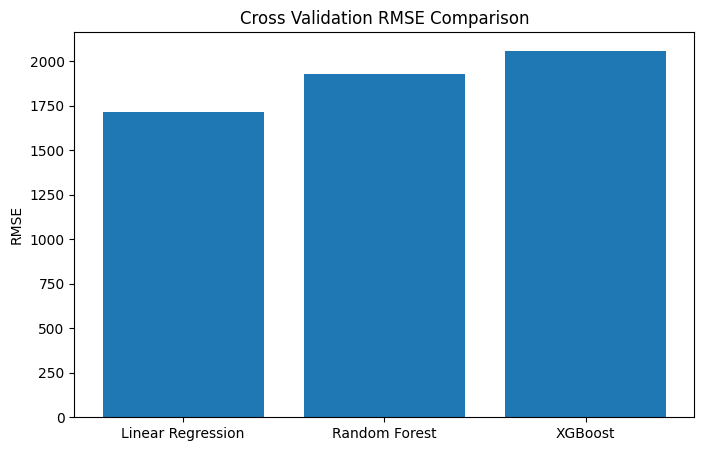

In [58]:
plt.figure(figsize=(8,5))

plt.bar(cv_results["Model"], cv_results["Average RMSE"])

plt.title("Cross Validation RMSE Comparison")

plt.ylabel("RMSE")
plt.savefig("Cross Validation RMSE Comparison.png", dpi=300)
plt.show()